In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [135]:
# email classification
# subject_formality_score -> ne kadar resmi bir dille yazılmış onun skoru
# sender_relationship_score -> Yollanan kişinin tanıdıklık skoru
# email_type = 0 -> Personal, 1 = Work email

In [136]:
df = pd.read_csv('9-email_classification_svm.csv')

In [137]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [138]:
df.describe()

,subject_formality_score,sender_relationship_score,email_type
count,1000.000000,1000.000000,1000.000000
mean,-1.009046,-0.006300,0.498000
std,0.654219,1.059501,0.500246
min,-3.532770,-2.218219,0.000000
25%,-1.252867,-1.006076,0.000000
50%,-0.994760,0.439233,0.000000
75%,-0.754839,0.994943,1.000000
max,2.180933,1.699497,1.000000


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


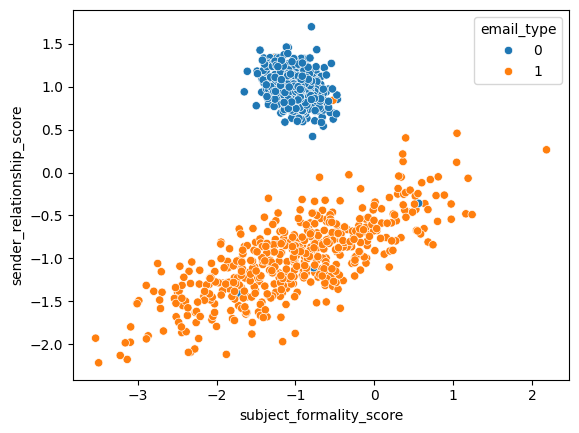

In [140]:
sns.scatterplot(x=df["subject_formality_score"], y=df["sender_relationship_score"], hue=df["email_type"])
plt.show()

In [141]:
X = df.drop("email_type", axis=1)
y = df["email_type"]

In [142]:
from sklearn.model_selection import train_test_split

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [144]:
X_train

,subject_formality_score,sender_relationship_score
846,-1.076655,0.943601
969,-1.062554,1.148473
191,-0.904298,1.049447
711,-1.283609,-1.171544
967,-1.097239,1.388281
...,...,...
887,-1.153241,1.241387
645,-0.964472,1.235402
908,-0.862866,1.110327
757,-1.124572,0.967717


In [145]:
########
from sklearn.svm import SVC

In [146]:
svc = SVC(kernel='linear')

In [147]:
svc.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [148]:
y_pred = svc.predict(X_test)

In [149]:
from sklearn.metrics import classification_report, confusion_matrix

In [150]:
print("classification_report: ", classification_report(y_test,y_pred))
print("confusion_matrix: \n", confusion_matrix(y_test,y_pred))

classification_report:                precision    recall  f1-score   support

           0       1.00      0.99      1.00       118
           1       0.99      1.00      1.00       132

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

confusion_matrix: 
 [[117   1]
 [  0 132]]


In [151]:
rbf = SVC() # kernel vermedim çünkü default değeri zaten rbf.
rbf.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [152]:
y_pred = rbf.predict(X_test)

In [153]:
print("classification_report: ", classification_report(y_test,y_pred))
print("confusion_matrix: \n", confusion_matrix(y_test,y_pred))

classification_report:                precision    recall  f1-score   support

           0       1.00      0.99      1.00       118
           1       0.99      1.00      1.00       132

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

confusion_matrix: 
 [[117   1]
 [  0 132]]


In [154]:
####################################################################################################################################################

In [155]:
df = pd.read_csv('9-loan_risk_svm.csv')

In [156]:
df.head()

,credit_score_fluctuation,recent_transaction_volume,loan_risk
0,-1.439860,1.283010,1
1,-0.276571,-1.232382,0
2,1.312047,0.955097,1
3,1.020706,0.089485,0
4,1.513729,0.580520,1


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   credit_score_fluctuation   1000 non-null   float64
 1   recent_transaction_volume  1000 non-null   float64
 2   loan_risk                  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [158]:
# credit_score_fluctuation -> Müşterinin kredi skorundaki dalgalanma
# recent_transaction_volume -> Son birkaç ayda yapılan finansal işlemlerin hacmi
# loan_risk -> 1 = riskli müşteri , 0 = risk yok

In [159]:
df.describe()

,credit_score_fluctuation,recent_transaction_volume,loan_risk
count,1000.000000,1000.000000,1000.000000
mean,-0.024200,-0.018748,0.504000
std,1.257080,1.222329,0.500234
min,-3.562160,-2.641815,0.000000
25%,-1.001007,-0.995190,0.000000
50%,-0.105200,-0.142727,1.000000
75%,1.007451,0.964210,1.000000
max,2.984892,3.338639,1.000000


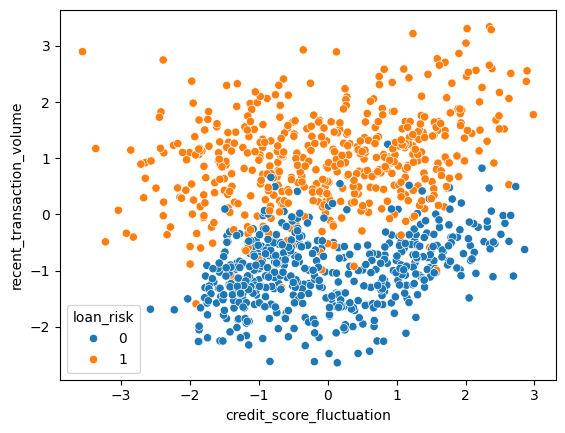

In [160]:
sns.scatterplot(x=df["credit_score_fluctuation"], y=df["recent_transaction_volume"], hue=df["loan_risk"])
plt.show()

In [161]:
X = df.drop("loan_risk", axis=1)
y = df["loan_risk"]

In [162]:
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [163]:
linear = SVC(kernel='linear')
linear.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [164]:
y_pred3 = linear.predict(X_test)
print( classification_report(y_test, y_pred3))
print("confusion_matrix: \n", confusion_matrix(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       121
           1       0.91      0.93      0.92       129

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

confusion_matrix: 
 [[109  12]
 [  9 120]]


In [165]:
rbf = SVC(kernel='rbf')
rbf.fit(X_train, y_train)
y_pred4 = rbf.predict(X_test)
print( classification_report(y_test, y_pred4))
print("confusion_matrix: \n", confusion_matrix(y_test,y_pred4))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       121
           1       0.94      0.91      0.93       129

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

confusion_matrix: 
 [[113   8]
 [ 11 118]]


In [166]:
poly = SVC(kernel='poly')
poly.fit(X_train, y_train)
y_pred5 = poly.predict(X_test)
print( classification_report(y_test, y_pred5))
print("confusion_matrix: \n", confusion_matrix(y_test,y_pred5))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91       121
           1       0.90      0.94      0.92       129

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

confusion_matrix: 
 [[107  14]
 [  8 121]]


In [167]:
sigmoid = SVC(kernel='sigmoid')
sigmoid.fit(X_train, y_train)
y_pred6 = sigmoid.predict(X_test)
print( classification_report(y_test, y_pred6))
print("confusion_matrix: \n", confusion_matrix(y_test,y_pred6))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       121
           1       0.83      0.84      0.84       129

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250

confusion_matrix: 
 [[ 98  23]
 [ 20 109]]


In [168]:
# hyperparameter tuning

In [169]:
SVC()

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [170]:
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "kernel": ["rbf", "linear", "poly", "sigmoid"],
    "gamma": ["scale", "auto"] # ---> Gamma, bir training örneğinin etki alanını belirler. Yani bir veri noktasının etrafında "etki balonu" gibi
}

In [171]:
from sklearn.model_selection import GridSearchCV

In [172]:
grid = GridSearchCV(SVC(), param_grid=param_grid, cv = 5)

In [173]:
grid.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [174]:
grid.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [175]:
y_pred7 = grid.predict(X_test)
print(classification_report(y_test,y_pred7))
print(confusion_matrix(y_test,y_pred7))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       121
           1       0.93      0.92      0.93       129

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[112   9]
 [ 10 119]]


In [176]:
######################################################################################################################################################

In [177]:
df = pd.read_csv('9-seismic_activity_svm.csv')

In [178]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [180]:
df.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


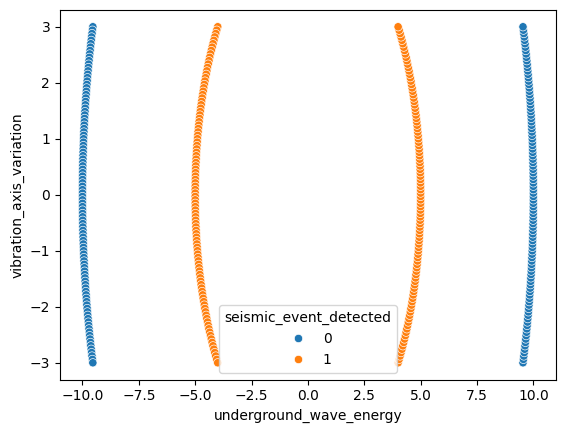

In [181]:
sns.scatterplot(x=df["underground_wave_energy"], y=df["vibration_axis_variation"], hue=df["seismic_event_detected"])
plt.show()

In [182]:
# manuel rbf kernel # ----> 3D YAPIP DÜZGÜN MODELLE DATALARI AYIRABİLİRİZ

In [183]:
df.columns

Index(['underground_wave_energy', 'vibration_axis_variation',
       'seismic_event_detected'],
      dtype='object')

In [184]:
df["underground_wave_energy **2"] = df["underground_wave_energy"] **2
df["vibration_axis_variation **2"] = df["underground_wave_energy"] **2
df["underground_wave_energy * vibration_axis_variation"] = df["underground_wave_energy"]*df["vibration_axis_variation"]

In [185]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected,underground_wave_energy **2,vibration_axis_variation **2,underground_wave_energy * vibration_axis_variation
0,9.539392,-3.000000,0,91.000000,91.000000,-28.618176
1,9.558241,-2.939394,0,91.359963,91.359963,-28.095434
2,9.576669,-2.878788,0,91.712580,91.712580,-27.569197
3,9.594678,-2.818182,0,92.057851,92.057851,-27.039548
4,9.612272,-2.757576,0,92.395776,92.395776,-26.506569


In [186]:
X = df.drop("seismic_event_detected", axis=1)
y = df["seismic_event_detected"]

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [188]:
X_train

,underground_wave_energy,vibration_axis_variation,underground_wave_energy **2,vibration_axis_variation **2,underground_wave_energy * vibration_axis_variation
135,-9.961312,0.878788,99.227732,99.227732,-8.753880
170,-9.922519,-1.242424,98.456382,98.456382,12.327978
368,-4.872667,-1.121212,23.742883,23.742883,5.463293
77,9.860133,1.666667,97.222222,97.222222,16.433555
12,9.738311,-2.272727,94.834711,94.834711,-22.132526
...,...,...,...,...,...
384,-4.541817,-2.090909,20.628099,20.628099,9.496526
375,-4.755162,-1.545455,22.611570,22.611570,7.348887
133,-9.949874,1.000000,99.000000,99.000000,-9.949874
396,-4.130115,-2.818182,17.057851,17.057851,11.639415


In [189]:
import plotly.express as px


In [190]:
fig = px.scatter_3d(df, 
                    x="underground_wave_energy **2", 
                    y="vibration_axis_variation **2", 
                    z="underground_wave_energy * vibration_axis_variation",                     
                    color="seismic_event_detected")
fig.show()

In [191]:
linear = SVC(kernel="linear")
linear.fit(X_train,y_train)

y_pred8 = linear.predict(X_test)
print(classification_report(y_test, y_pred8))
print(confusion_matrix(y_test,y_pred8))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        52

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[48  0]
 [ 0 52]]


In [192]:
# automatic rbf 

In [193]:
df = pd.read_csv("9-seismic_activity_svm.csv")

In [194]:
X = df.drop("seismic_event_detected", axis=1)
y = df["seismic_event_detected"]

In [195]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [196]:
linear = SVC(kernel="linear")
linear.fit(X_train,y_train)

y_pred9 = linear.predict(X_test)
print(classification_report(y_test, y_pred9))
print(confusion_matrix(y_test,y_pred9))

              precision    recall  f1-score   support

           0       0.48      1.00      0.65        48
           1       0.00      0.00      0.00        52

    accuracy                           0.48       100
   macro avg       0.24      0.50      0.32       100
weighted avg       0.23      0.48      0.31       100

[[48  0]
 [52  0]]


c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [197]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train,y_train)

y_pred10 = rbf.predict(X_test)
print(classification_report(y_test, y_pred10))
print(confusion_matrix(y_test,y_pred10))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        52

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[48  0]
 [ 0 52]]
